# Exoplanet Demographic Survey

**A statistical investigation of ~6,300 confirmed exoplanets from the NASA Exoplanet Archive**

*Author: Ali (Astro-alii) — BSc Computer Science, University of Greenwich*

---

## Thesis

1. **Detection bias, not nature, shapes what we've found.**
2. **Mass and radius aren't independent — they follow a physical law, not a scatter.**
3. **The search for Earth-like planets is still an edge case, not the norm.**


## 1. Data Source

**Dataset:** NASA Exoplanet Archive — Planetary Systems (PS) table
**Downloaded:** July 18, 2026
**Filter applied:** `default_flag = 1`
**Row count after filtering:** 6,324 planets

```
https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+pl_name,hostname,discoverymethod,disc_year,
pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_insol,pl_eqt,st_teff,st_rad,st_mass,sy_dist+from+ps+where+default_flag=1&format=csv
```


## 2. Discoveries Over Time by Detection Method

**Library:** Matplotlib · **Type:** Stacked bar chart


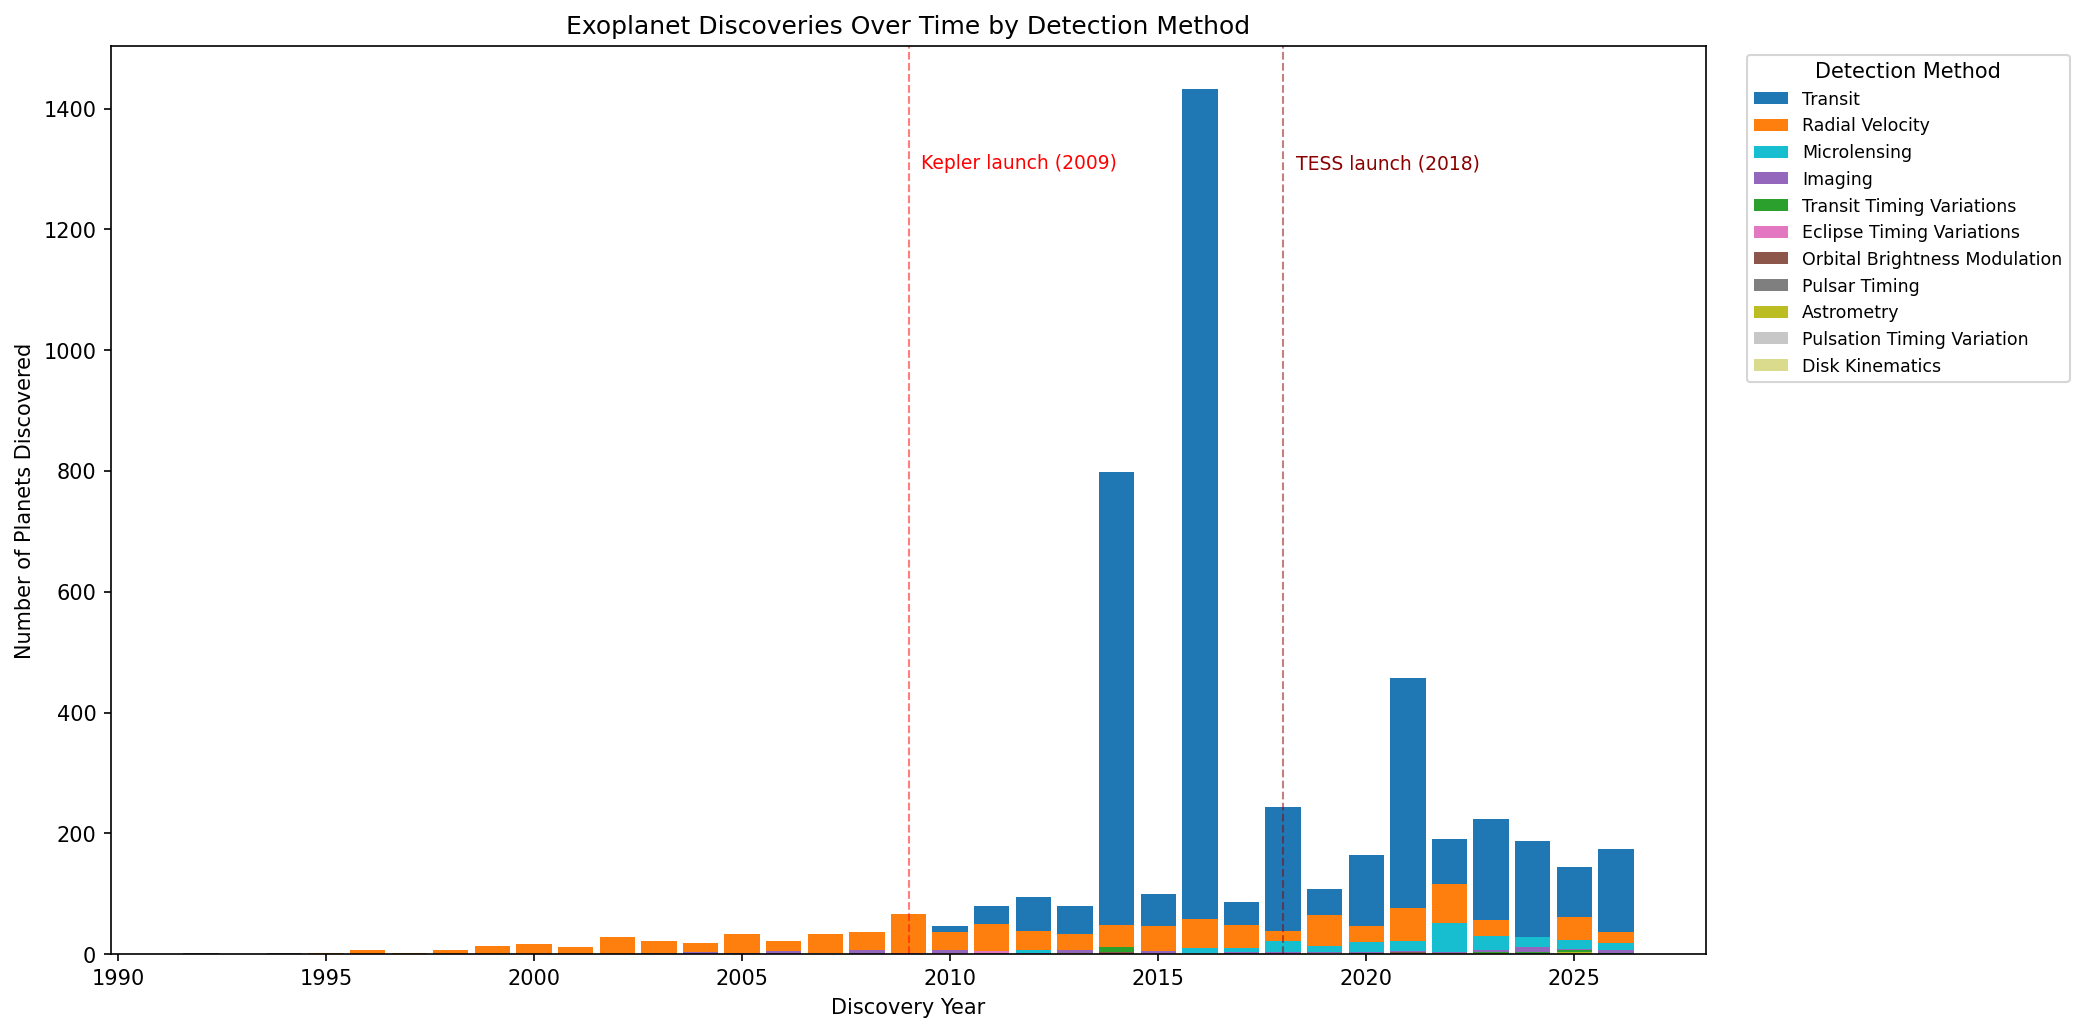

In [1]:
import matplotlib.pyplot as  plt 
import pandas as pd

df = pd.read_csv("raw_data_files/exoplanets_raw.csv" , comment = "#")
df_clean = df.dropna(subset=['disc_year', 'discoverymethod'])

grouped = df_clean.groupby(['disc_year', 'discoverymethod'])



counts = grouped.size()
clean_table = counts.unstack(fill_value =0)

years = clean_table.index
# discovery methods
transit = clean_table["Transit"] 
radial_velocity = clean_table["Radial Velocity"]
microlensing = clean_table["Microlensing"]
imaging = clean_table["Imaging"]
transit_timing_variations = clean_table["Transit Timing Variations"]
eclipse_timing_variations = clean_table["Eclipse Timing Variations"]
orbital_brightness_modulation = clean_table["Orbital Brightness Modulation"]
pulsar_timing = clean_table ["Pulsar Timing"]
astrometry = clean_table["Astrometry"]
pulsation_timing_variation = clean_table["Pulsation Timing Variations"]
disk_kinematics = clean_table["Disk Kinematics"]


bar_width = 0.85
fig , ax = plt.subplots(figsize = (14 , 7))
plt.bar(years , transit , color = "#1f77b4" , label = "Transit" , width= bar_width)
plt.bar(years , radial_velocity , color = "#ff7f0e" ,label = "Radial Velocity", width = bar_width)
plt.bar(years , microlensing , color = "#17becf" , label = "Microlensing", width = bar_width)
plt.bar(years , imaging, color = "#9467bd" , width = bar_width , label = "Imaging")
plt.bar(years , transit_timing_variations , color = "#2ca02c" , width = bar_width, label = "Transit Timing Variations")
plt.bar(years , eclipse_timing_variations , color = "#e377c2" , width = bar_width, label = "Eclipse Timing Variations")
plt.bar(years , orbital_brightness_modulation , color = "#8c564b" , width = bar_width, label = "Orbital Brightness Modulation")
plt.bar(years , pulsar_timing , color = "#7f7f7f" , width = bar_width , label = "Pulsar Timing")
plt.bar(years , astrometry , color = "#bcbd22" , width = bar_width , label = "Astrometry")
plt.bar(years , pulsation_timing_variation , color = "#c7c7c7" , width = bar_width, label = "Pulsation Timing Variation")
plt.bar(years , disk_kinematics , color = "#dbdb8d", width = bar_width, label = "Disk Kinematics")


ax.set_xlabel('Discovery Year')
ax.set_ylabel('Number of Planets Discovered')
ax.set_title('Exoplanet Discoveries Over Time by Detection Method')
ax.legend(title='Detection Method', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

ax.axvline(x=2009, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(2009.3, 1300, 'Kepler launch (2009)', color='red', fontsize=9, rotation=0)

ax.axvline(x=2018, color='darkred', linestyle='--', alpha=0.5, linewidth=1)
ax.text(2018.3, 1300, 'TESS launch (2018)', color='darkred', fontsize=9)




plt.tight_layout()
#plt.savefig("graph1_discoveries_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

**What this reveals:** discovery counts jump sharply in 2014 and 2016, driven by batch confirmations of Kepler mission candidates rather than a natural increase in the rate of planet formation. Radial Velocity dominates the pre-2009 era; Transit takes over almost completely once Kepler comes online in 2009, and again with TESS from 2018. The shape of this timeline is a history of telescopes, not a history of the universe — direct support for thesis point 1.


## 3. Discoveries by Detection Method

**Library:** Matplotlib · **Type:** Horizontal bar chart, ranked


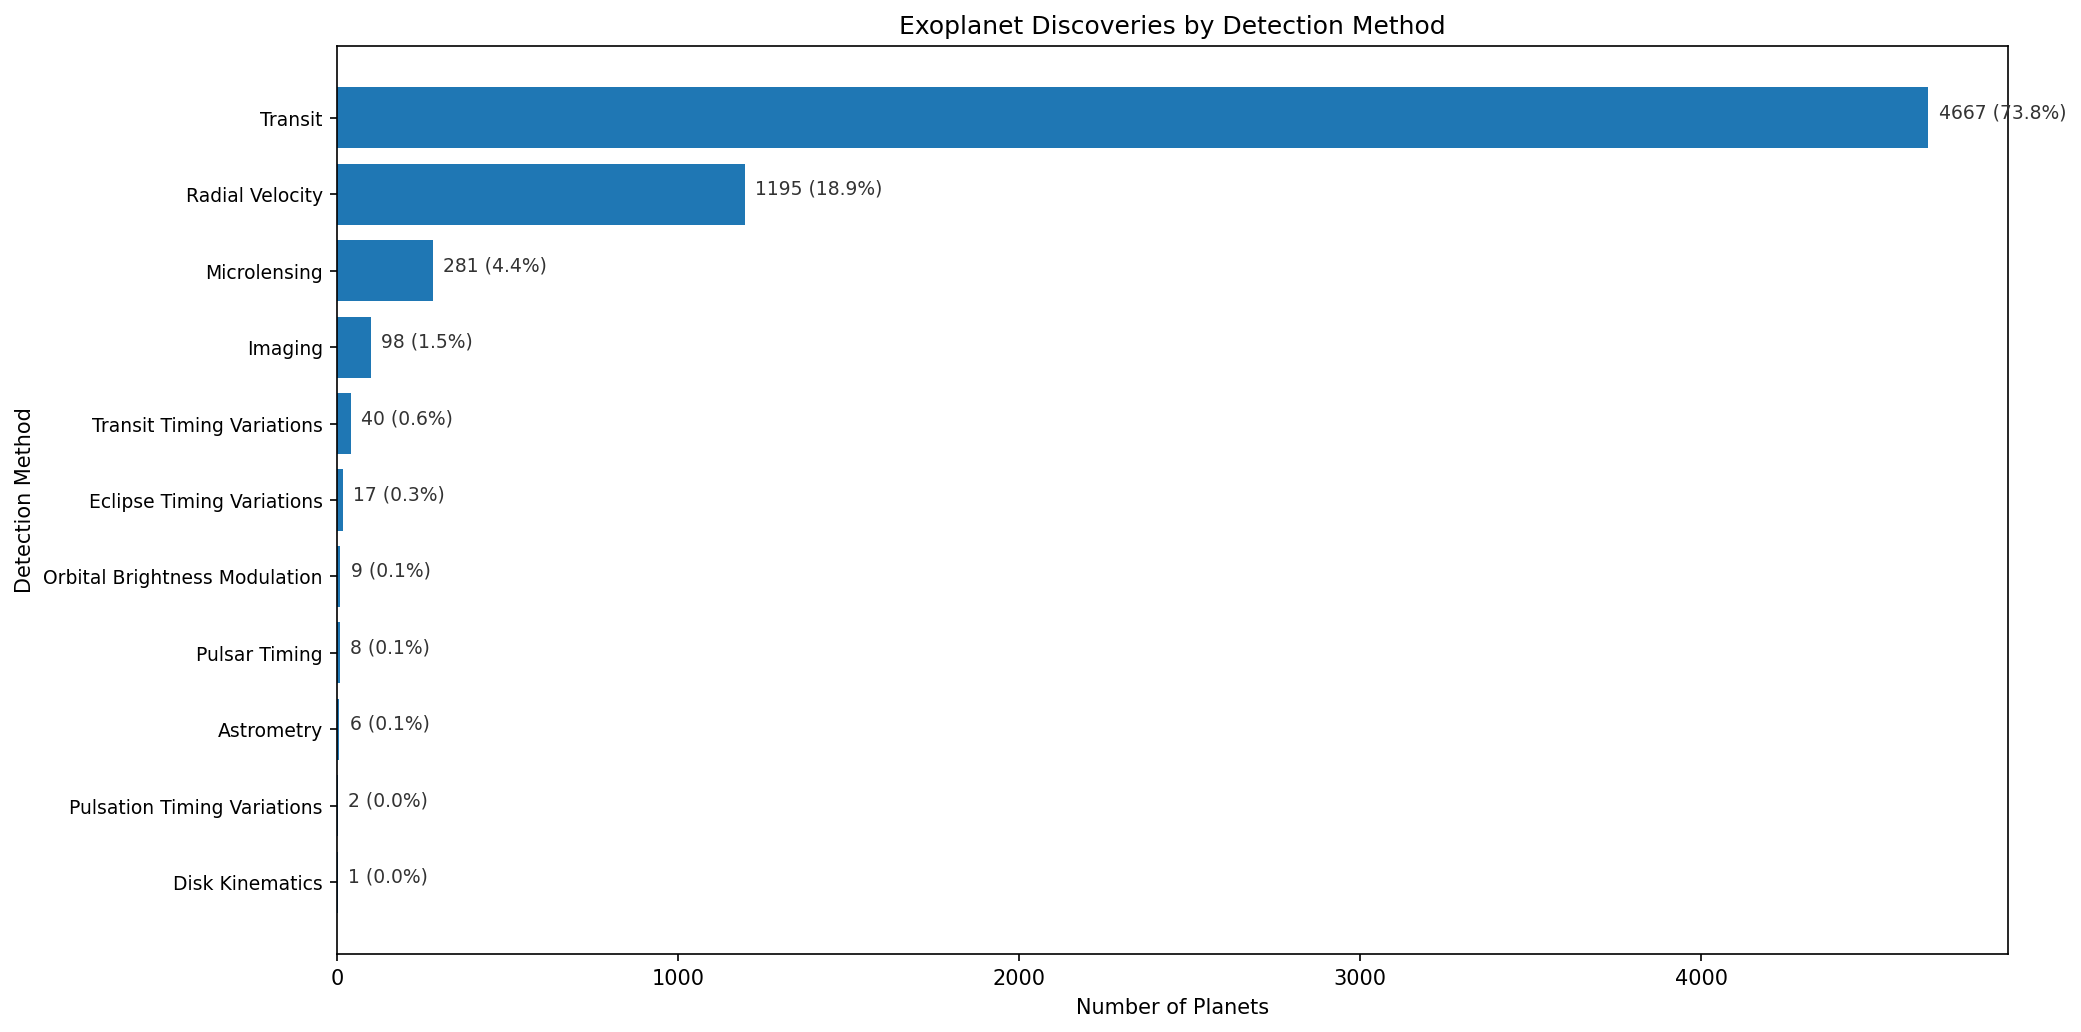

In [ ]:
import matplotlib.pyplot as plt 
import pandas as pd 

df = pd.read_csv("raw_data_files/exoplanets_raw.csv" , comment = "#")
df_clean = df.dropna(subset = ["discoverymethod"])

method_counts = df_clean["discoverymethod"].value_counts()

fig , ax = plt.subplots(figsize= (14, 7))
ax.barh(method_counts.index , method_counts.values) 
ax.invert_yaxis()

total_planets = sum(method_counts.values)


for index , count in enumerate (method_counts):
    percent = (count / total_planets) * 100
    ax.text (count +30  ,index , f"{count} ({percent:.1f}%)", fontsize = 9 , color= "#333333") 

ax.set_xlabel('Number of Planets')
ax.set_ylabel('Detection Method')
ax.tick_params(axis='y', labelsize=9)
ax.set_title('Exoplanet Discoveries by Detection Method')

plt.tight_layout()

plt.show()

**What this reveals:** Transit (73.8%) and Radial Velocity (18.9%) together account for 92.7% of every confirmed exoplanet in the archive. The remaining nine methods combined make up less than 7.3% of the dataset — a direct, quantified measure of detection bias.


## 4. Mass-Radius Relationship

**Library:** Plotly (interactive) · **Type:** Log-log scatter

Run the cell below to render the interactive chart.


In [ ]:
import plotly.express as px
import pandas as pd

df = pd.read_csv("raw_data_files/exoplanets_raw.csv" , comment = "#")
df_clean = df.dropna(subset = ["pl_masse" , "pl_rade"])


fig = px.scatter(df_clean, df_clean["pl_masse"], df_clean["pl_rade"], log_x= True , log_y= True,
                 color = "discoverymethod",
                 hover_name="pl_name", 
                 hover_data=["hostname", "disc_year"], 
                 labels = {"pl_masse": "Planet Mass (Earth Masses)",
                           "pl_rade":"Planet Radius (Earth Radii)", 
                           "discoverymethod": "Detection Method"},
                 title = "Exoplanet Mass-Radius Relationships")
                    
#Pnadas df from scratch
reference_planets = pd.DataFrame({
    'name': ['Earth', 'Neptune', 'Jupiter'],
    'mass': [1, 17.15, 317.8],
    'radius': [1, 3.88, 11.2]
})

fig.add_scatter(
    x=reference_planets['mass'],      # 3 x-positions: 1, 17.15, 317.8
    y=reference_planets['radius'],    # 3 y-positions: 1, 3.88, 11.2
    mode='markers+text',              # draw both a dot AND a text label
    text=reference_planets['name'],   # the actual words to display: 'Earth', 'Neptune', 'Jupiter'
    textposition='top center',        # position the text just above each dot
    marker=dict(size=14, color='black', symbol='star'),  # make these dots stand out — bigger, black, star-shaped
    name='Solar System Reference'     # what this layer is called in the legend
)



fig.show ()

**What this reveals:** planets trace a tight diagonal band from roughly 0.1 to 10 Earth masses, then flatten into a plateau around 10-13 Earth radii from ~10 Earth masses up into the thousands — evidence that gravitational compression, not simple mass accumulation, governs giant planet structure. Direct support for thesis point 2.


## 5. Orbital Period vs. Semi-Major Axis — Verifying Kepler's Third Law

**Library:** Matplotlib · **Type:** Log-log scatter with theoretical overlay


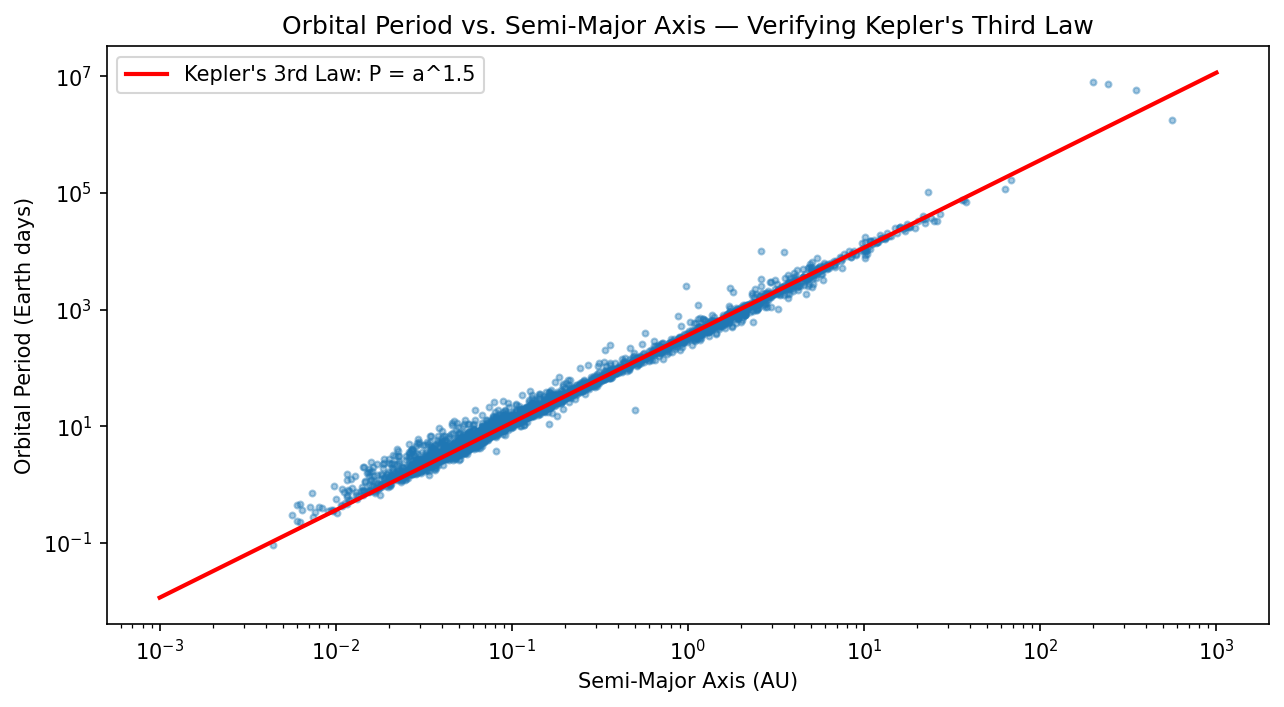

In [ ]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np 

df = pd.read_csv("raw_data_files/exoplanets_raw.csv" , comment = "#")
df_clean = df.dropna(subset = ["pl_orbsmax" , "pl_orbper"])



fig , ax = plt.subplots(figsize = (10,5))
ax.scatter (df_clean["pl_orbsmax"] , df_clean["pl_orbper"],color='#1f77b4', s=8, alpha=0.4) # s=marker size, aplha= transparency control
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Semi-Major Axis (AU)")
ax.set_ylabel("Orbital Period (Earth days)")
ax.set_title("Orbital Period vs. Semi-Major Axis — Verifying Kepler's Third Law")


#theoretically predicted plot , satisfying Kepler's Third Law
a_range = np.logspace(-3, 3, 100)
p_theoretical = a_range ** 1.5 * 365.25
ax.plot(a_range, p_theoretical, color='red', linewidth=2, label="Kepler's 3rd Law: P = a^1.5")

ax.legend()




plt.show()

**What this reveals:** the theoretical Kepler's Third Law curve tracks the real observed data almost exactly across six orders of magnitude in orbital distance — confirming that a law derived over 400 years ago from six solar system planets holds for thousands of planets orbiting entirely different stars. Direct support for thesis point... and a strong independent physics confirmation in its own right.


## 6. Habitable Zone Candidates

**Library:** Plotly (interactive) · **Type:** Scatter with reference zone

Run the cell below to render the interactive chart.


In [ ]:
import plotly.express as px 
import pandas as pd 

df = pd.read_csv("raw_data_files/exoplanets_raw.csv" , comment = "#")
df_clean = df.dropna(subset = ["pl_eqt", "pl_rade"])


fig = px.scatter(
    df_clean,
    x='pl_eqt',
    y='pl_rade',
    
    color='discoverymethod',
    hover_name='pl_name',
    hover_data=['hostname', 'pl_orbper', 'st_teff'],
    labels={
        'pl_eqt': 'Equilibrium Temperature (K)',
        'pl_rade': 'Planet Radius (Earth Radii)',
        'discoverymethod': 'Detection Method'
    },
    title='Exoplanet Habitable Zone Candidates'
)
fig.add_shape(
    type="rect",
    x0=200, x1=320,
    y0=0.8, y1=1.6,
    line=dict(color="green", dash="dash"),
    fillcolor="green",
    opacity=0.15

)

fig.add_annotation(
    x=260, y=1.9,
    text="Roughly Earth-like zone",
    showarrow=False,
    font=dict(color="green", size=12)
)





fig.show()

**What this reveals:** out of 6,324 confirmed exoplanets, only a small handful fall inside or near the shaded Earth-like zone — evidence that finding true Earth analogs is still at the edge of current detection capability, not evidence that such planets are rare in the universe. Direct support for thesis point 3.


## 7. Conclusion

1. **The exoplanet catalog is a record of telescope capability as much as it is a record of nature.** 92.7% of all confirmed planets come from just two of eleven possible detection methods.
2. **Beneath that bias, real, provable physics holds.** The mass-radius relationship shows a genuine compositional split, and Kepler's 400-year-old Third Law accurately predicts orbital periods for thousands of planets it was never derived from.
3. **True Earth analogs remain the frontier, not the finding.**

## Stack

Python · pandas · NumPy · Matplotlib · Plotly
